# Complete Floorplan Workflow

This notebook documents the current floorplan generation workflow in this repository.

The implemented path in this notebook is:

Natural language prompt -> prompt expansion -> explicit edge extraction -> graph generation -> extracted-edge filtering -> canonical serialization (baseline) -> learned edge completion (optional) -> canonical serialization (final).

It uses the code in `text_to_graph/` together with the shared graph schema in `graphs/`.

## Codebase map

- `text_to_graph/prompt_expander.py`: expands the user prompt into a complete room set.
- `text_to_graph/edge_extractor.py`: extracts only explicit room-to-room relationships from the original prompt.
- `text_to_graph/graph_generator.py`: generates canonical serialized graph output using expanded room context.
- `text_to_graph/edge_completion.py`: predicts additional plausible missing edges from room nodes plus partial observed edges.
- `text_to_graph/workflow.py`: orchestrates prompt expansion, explicit edge extraction, graph generation, edge filtering, and optional learned edge completion.
- `text_to_graph/schemas.py`: Pydantic schema for the LLM exchange format.
- `graphs/schema.py`: shared `RoomNode`, `RoomEdge`, and `FloorplanGraph` dataclasses.
- `graphs/for_resplan/serialize_graph.py`: deterministic graph serialization for canonical text.

Current boundary:
- The workflow now reaches a completed topology graph (explicit edges + optional learned completion).
- The layout and floorplan rasterization stages remain downstream work.

In [134]:
import importlib
import os
import sys
from pathlib import Path

from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "text_to_graph").exists():
    PROJECT_ROOT = Path(__file__).resolve().parent if "__file__" in globals() else PROJECT_ROOT
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

load_dotenv(PROJECT_ROOT / ".env")

import text_to_graph.workflow as workflow_module
import text_to_graph.edge_completion as edge_completion_module
importlib.reload(workflow_module)
importlib.reload(edge_completion_module)
FloorplanWorkflow = workflow_module.FloorplanWorkflow
CompletionConfig = edge_completion_module.CompletionConfig
EdgeCompletionPredictor = edge_completion_module.EdgeCompletionPredictor

from graphs.schema import RoomNode, RoomEdge, FloorplanGraph
from graphs.for_resplan.serialize_graph import graph_to_canonical_text

API_KEY = os.getenv("api_key") or os.getenv("NVIDIA_API_KEY") or os.getenv("OPENAI_API_KEY")
MODEL = os.getenv("FLOORPLAN_LLM_MODEL", "mistralai/mistral-small-4-119b-2603")
BASE_URL = os.getenv("OPENAI_BASE_URL", "https://integrate.api.nvidia.com/v1")
EDGE_COMPLETION_MODEL_PATH = os.getenv(
    "EDGE_COMPLETION_MODEL_PATH", str(PROJECT_ROOT / "trained_models" / "best_edge_completion.pt")
)
EDGE_COMPLETION_THRESHOLD = float(os.getenv("EDGE_COMPLETION_THRESHOLD", "0.30"))
EDGE_COMPLETION_MAX_ADDED = int(os.getenv("EDGE_COMPLETION_MAX_ADDED", "24"))

if not API_KEY:
    raise ValueError("Set api_key, NVIDIA_API_KEY, or OPENAI_API_KEY in the project .env file")

# Keep workflow generation to explicit edges only; completion is applied in a later notebook step.
workflow = FloorplanWorkflow(
    api_key=API_KEY,
    model=MODEL,
    base_url=BASE_URL,
    edge_completion_model_path=None,
)

edge_completer = None
if Path(EDGE_COMPLETION_MODEL_PATH).exists():
    edge_completer = EdgeCompletionPredictor(
        EDGE_COMPLETION_MODEL_PATH,
        config=CompletionConfig(
            threshold=EDGE_COMPLETION_THRESHOLD,
            max_added_edges=EDGE_COMPLETION_MAX_ADDED,
        ),
    )

print(f"Project root: {PROJECT_ROOT}")
print(f"Model: {MODEL}")
print(f"Base URL: {BASE_URL}")
print(f"Edge completion model path: {EDGE_COMPLETION_MODEL_PATH}")
print(f"Edge completion checkpoint exists: {Path(EDGE_COMPLETION_MODEL_PATH).exists()}")
print(f"Edge completion loaded: {edge_completer is not None}")
print(f"Edge completion threshold: {EDGE_COMPLETION_THRESHOLD}")
print(f"Edge completion max added edges: {EDGE_COMPLETION_MAX_ADDED}")

Project root: /home/dexter/projects/FloorPlan-Pipeline
Model: mistralai/mistral-small-4-119b-2603
Base URL: https://integrate.api.nvidia.com/v1
Edge completion model path: /home/dexter/projects/FloorPlan-Pipeline/trained_models/best_edge_completion.pt
Edge completion checkpoint exists: True
Edge completion loaded: True
Edge completion threshold: 0.3
Edge completion max added edges: 24


## Sample prompt

The workflow is designed to convert a natural language request into a canonical floorplan graph.

The example below uses a small apartment description that matches the current room vocabulary supported by the repository.

In [135]:
sample_prompt = (
    "A compact 2BHK apartment with a living room, a kitchen next to the living room, "
    "two bedrooms, one bathroom, and a front door connected to the living area."
)

expanded = workflow.expand_prompt(sample_prompt)
print("Original rooms:", expanded.original_rooms)
print("Added rooms:", expanded.added_rooms)
print("All rooms:", expanded.all_rooms)
print("Reasoning:", expanded.reasoning)
print("Spatial context:", expanded.spatial_context)

Original rooms: ['living', 'kitchen', 'bedroom', 'bathroom', 'front_door']
Added rooms: []
All rooms: ['living', 'kitchen', 'bedroom', 'bathroom', 'front_door']
Reasoning: The original description already includes all essential room types (living, kitchen, two bedrooms, bathroom, front_door) and meets the requirements for a complete residential floorplan. No additional rooms are needed.
Spatial context: Compact layout with a central living area serving as the primary gathering space. The kitchen is adjacent to the living room for ease of movement during cooking or socializing. Two bedrooms are separated from the living area for privacy, with one bathroom serving both bedrooms. The front door connects directly to the living space, implying an open or efficient entry flow.


## Generate graph and inspect objects

This section is intentionally split into two phases:
1. expand the prompt
2. extract explicit room-to-room edges from the original prompt
3. generate the graph schema (filtered to extracted edges)
4. serialize the explicit-edge graph first
5. auto-sweep edge-completion threshold and max-added edges in the next cell
6. stop when a valid graph is found and re-serialize for downstream geometry/layout

In [136]:
extracted_edges = workflow.extract_explicit_edges(sample_prompt, expanded)
graph_schema = workflow.generate_graph(expanded, sample_prompt, extracted_edges)

room_type_by_id = {room.id: room.type for room in graph_schema.rooms}
ids_by_type = {}
for room in graph_schema.rooms:
    ids_by_type.setdefault(room.type, []).append(room.id)

print("Extracted explicit edges:")
if extracted_edges.edges:
    for edge in extracted_edges.edges:
        print(
            f"  - {edge.src_type} -> {edge.dst_type} "
            f"(relation: {edge.relation}, direction: {edge.direction})"
        )
else:
    print("  - none")

def edge_key(src, dst):
    return tuple(sorted((src, dst)))

def explicit_pair_key(src_type, dst_type):
    return tuple(sorted((src_type, dst_type)))

def normalized_relation(src_type, dst_type, explicit_relation):
    if explicit_relation:
        return explicit_relation
    if "front_door" in {src_type, dst_type}:
        return "via_door"
    return "adjacency"

# Build explicit rule set from extracted pairs.
explicit_rules = []
for e in extracted_edges.edges:
    explicit_rules.append(
        {
            "src_type": e.src_type,
            "dst_type": e.dst_type,
            "pair": explicit_pair_key(e.src_type, e.dst_type),
            "relation": e.relation,
            "direction": e.direction,
        }
    )

# Keep only generated edges whose room types match extracted explicit pairs.
filtered_edges = []
filtered_keys = set()
edge_cls = graph_schema.edges[0].__class__ if graph_schema.edges else None

if explicit_rules and edge_cls is not None:
    for gen_edge in graph_schema.edges:
        src_t = room_type_by_id.get(gen_edge.src)
        dst_t = room_type_by_id.get(gen_edge.dst)
        if src_t is None or dst_t is None:
            continue
        pair = explicit_pair_key(src_t, dst_t)
        matched_rule = next((r for r in explicit_rules if r["pair"] == pair), None)
        if matched_rule is None:
            continue

        rel = normalized_relation(src_t, dst_t, matched_rule["relation"] or gen_edge.relation)
        k = edge_key(gen_edge.src, gen_edge.dst)
        if k in filtered_keys:
            continue
        filtered_keys.add(k)
        filtered_edges.append(
            edge_cls(
                src=gen_edge.src,
                dst=gen_edge.dst,
                relation=rel,
                direction=matched_rule["direction"],
            )
        )

# Ensure each extracted explicit pair exists at least once.
if explicit_rules and edge_cls is not None:
    for rule in explicit_rules:
        src_candidates = ids_by_type.get(rule["src_type"], [])
        dst_candidates = ids_by_type.get(rule["dst_type"], [])
        if not src_candidates or not dst_candidates:
            continue

        added = False
        for src_id in src_candidates:
            for dst_id in dst_candidates:
                if src_id == dst_id:
                    continue
                k = edge_key(src_id, dst_id)
                if k in filtered_keys:
                    added = True
                    break
                filtered_keys.add(k)
                filtered_edges.append(
                    edge_cls(
                        src=src_id,
                        dst=dst_id,
                        relation=normalized_relation(rule["src_type"], rule["dst_type"], rule["relation"]),
                        direction=rule["direction"],
                    )
                )
                added = True
                break
            if added:
                break

if explicit_rules and edge_cls is not None:
    graph_schema = graph_schema.model_copy(update={"edges": filtered_edges})

graph = FloorplanGraph(
    nodes=[
        RoomNode(id=room.id, type=room.type, role=room.role)
        for room in graph_schema.rooms
    ],
    edges=[
        RoomEdge(
            src=edge.src,
            dst=edge.dst,
            relation=edge.relation,
            direction=edge.direction,
        )
        for edge in graph_schema.edges
    ],
)

serialized_graph_before_completion = graph_to_canonical_text(graph)
serialized_graph = serialized_graph_before_completion

print("\nRooms in graph schema (before completion):")
for room in graph_schema.rooms:
    print(f"  - {room.id}: {room.type}")

print("\nEdges in graph schema (before completion):")
for edge in graph_schema.edges:
    if edge.direction:
        print(f"  - {edge.src} --[{edge.relation} {edge.direction}]--> {edge.dst}")
    else:
        print(f"  - {edge.src} --[{edge.relation}]--> {edge.dst}")

Extracted explicit edges:
  - kitchen -> living (relation: adjacency, direction: None)
  - front_door -> living (relation: via_door, direction: None)

Rooms in graph schema (before completion):
  - living_0: living
  - kitchen_0: kitchen
  - bedroom_0: bedroom
  - bedroom_1: bedroom
  - bathroom_0: bathroom
  - front_door_0: front_door

Edges in graph schema (before completion):
  - living_0 --[via_door]--> front_door_0
  - kitchen_0 --[adjacency]--> living_0


## Canonical serialization check (before completion)

This check validates canonical serialization for the explicit-edge graph before learned completion is applied.

In [137]:
print(serialized_graph_before_completion)
print()
print(
    "Matches canonical serializer (before completion):",
    serialized_graph_before_completion == graph_to_canonical_text(graph),
)
print("\nGraph object summary (before completion):")
print(f"Nodes: {len(graph.nodes)}")
for node in graph.nodes:
    print(f"  - {node.id}: {node.type}")
print(f"Edges: {len(graph.edges)}")
for edge in graph.edges:
    if edge.direction:
        print(f"  - {edge.src} --[{edge.relation} {edge.direction}]--> {edge.dst}")
    else:
        print(f"  - {edge.src} --[{edge.relation}]--> {edge.dst}")

bathroom_0: bathroom
bedroom_0: bedroom
bedroom_1: bedroom
front_door_0: front_door
kitchen_0: kitchen
living_0: living
living_0 via_door front_door_0
kitchen_0 adjacency living_0

Matches canonical serializer (before completion): True

Graph object summary (before completion):
Nodes: 6
  - living_0: living
  - kitchen_0: kitchen
  - bedroom_0: bedroom
  - bedroom_1: bedroom
  - bathroom_0: bathroom
  - front_door_0: front_door
Edges: 2
  - living_0 --[via_door]--> front_door_0
  - kitchen_0 --[adjacency]--> living_0


In [138]:
from collections import defaultdict, deque
from itertools import combinations

edges_before_completion = len(graph_schema.edges)
base_graph_schema = graph_schema.model_copy(deep=True)

room_types = {r.id: r.type for r in base_graph_schema.rooms}
room_ids = [r.id for r in base_graph_schema.rooms]

def undirected_key(a, b):
    return tuple(sorted((a, b)))

def pair_type(a, b):
    return tuple(sorted((room_types[a], room_types[b])))

ALLOWED_PAIRS = {
    ("balcony", "bedroom"),
    ("balcony", "kitchen"),
    ("balcony", "living"),
    ("bathroom", "bedroom"),
    ("bathroom", "living"),
    ("bedroom", "bedroom"),
    ("bedroom", "kitchen"),
    ("bedroom", "living"),
    ("front_door", "living"),
    ("kitchen", "living"),
}

def is_pair_allowed(a, b):
    if a == b:
        return False
    return pair_type(a, b) in ALLOWED_PAIRS

def default_relation(a, b, suggested_relation=None):
    # Keep via_door semantics only for front door access edges.
    if "front_door" in pair_type(a, b):
        return "via_door"
    return "adjacency"

def build_adj(edges):
    adj = {rid: set() for rid in room_ids}
    for e in edges:
        if e.src in adj and e.dst in adj and e.src != e.dst:
            adj[e.src].add(e.dst)
            adj[e.dst].add(e.src)
    return adj

def is_connected(edges):
    if not room_ids:
        return True
    adj = build_adj(edges)
    start = room_ids[0]
    seen = {start}
    q = deque([start])
    while q:
        cur = q.popleft()
        for nxt in adj[cur]:
            if nxt not in seen:
                seen.add(nxt)
                q.append(nxt)
    return len(seen) == len(room_ids)

def degree_map(edges):
    d = defaultdict(int)
    for e in edges:
        d[e.src] += 1
        d[e.dst] += 1
    return d

# Gather model proposals across a sweep: frequency works as a probability proxy.
candidate_stats = defaultdict(lambda: {"count": 0, "relation": "adjacency"})
sweep_runs = []

if edge_completer is not None:
    threshold_grid = [0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35, 0.30]
    max_added_grid = [4, 6, 8, 10, 12, 14, 16, 20]

    for th in threshold_grid:
        for mx in max_added_grid:
            edge_completer.config.threshold = th
            edge_completer.config.max_added_edges = mx
            cand = edge_completer.complete_graph(base_graph_schema.model_copy(deep=True))
            sweep_runs.append((th, mx, len(cand.edges)))
            for e in cand.edges:
                if not is_pair_allowed(e.src, e.dst):
                    continue
                k = undirected_key(e.src, e.dst)
                candidate_stats[k]["count"] += 1
                if e.relation == "via_door" and "front_door" in pair_type(e.src, e.dst):
                    candidate_stats[k]["relation"] = "via_door"

# Start from a sanitized baseline: keep only plausible undirected pairs.
selected = []
selected_keys = set()
for e in base_graph_schema.edges:
    if not is_pair_allowed(e.src, e.dst):
        continue
    k = undirected_key(e.src, e.dst)
    if k in selected_keys:
        continue
    selected_keys.add(k)
    rel = default_relation(e.src, e.dst, e.relation)
    selected.append(RoomEdge(src=e.src, dst=e.dst, relation=rel, direction=None))

def add_edge(a, b, relation="adjacency"):
    if not is_pair_allowed(a, b):
        return False
    k = undirected_key(a, b)
    if k in selected_keys:
        return False
    selected_keys.add(k)
    rel = default_relation(a, b, relation)
    selected.append(RoomEdge(src=a, dst=b, relation=rel, direction=None))
    return True

living = [rid for rid, t in room_types.items() if t == "living"]
kitchen = [rid for rid, t in room_types.items() if t == "kitchen"]
bedrooms = [rid for rid, t in room_types.items() if t == "bedroom"]
bathrooms = [rid for rid, t in room_types.items() if t == "bathroom"]
balconies = [rid for rid, t in room_types.items() if t == "balcony"]
doors = [rid for rid, t in room_types.items() if t == "front_door"]

# 1) Hard sensible anchors.
if living and kitchen:
    add_edge(living[0], kitchen[0], relation="adjacency")
if living and doors:
    add_edge(living[0], doors[0], relation="via_door")

# 2) Bathroom should prefer bedroom over living.
for ba in bathrooms:
    if bedrooms:
        best = max(bedrooms, key=lambda br: candidate_stats[undirected_key(ba, br)]["count"])
        add_edge(ba, best, relation="adjacency")
    elif living:
        add_edge(ba, living[0], relation="adjacency")

# 3) Bedrooms should connect to living or another bedroom.
for br in bedrooms:
    adj_now = build_adj(selected)
    if adj_now[br]:
        continue
    pool = []
    if living:
        pool.append(living[0])
    pool.extend([x for x in bedrooms if x != br])
    if not pool and kitchen:
        pool.append(kitchen[0])
    pool = [dst for dst in pool if is_pair_allowed(br, dst)]
    if pool:
        best = max(pool, key=lambda dst: candidate_stats[undirected_key(br, dst)]["count"])
        add_edge(br, best, relation="adjacency")

# 4) Balcony should connect to living/bedroom/kitchen (never bathroom).
for bl in balconies:
    pool = []
    if living:
        pool.append(living[0])
    pool.extend(bedrooms)
    pool.extend(kitchen)
    pool = [dst for dst in pool if is_pair_allowed(bl, dst)]
    if pool:
        best = max(pool, key=lambda dst: candidate_stats[undirected_key(bl, dst)]["count"])
        add_edge(bl, best, relation="adjacency")

# 5) Add strongest remaining model-backed edges under degree caps.
caps = {
    "front_door": 1,
    "bathroom": 2,
    "balcony": 2,
    "bedroom": 3,
    "kitchen": 3,
    "living": 5,
}

scored_pairs = []
for a, b in combinations(room_ids, 2):
    if not is_pair_allowed(a, b):
        continue
    k = undirected_key(a, b)
    if k in selected_keys:
        continue
    cnt = candidate_stats[k]["count"]
    pair = pair_type(a, b)
    prior = 0.0
    if pair == ("kitchen", "living"):
        prior += 2.5
    if pair == ("bathroom", "bedroom"):
        prior += 2.2
    if pair == ("bedroom", "living"):
        prior += 1.5
    if pair == ("front_door", "living"):
        prior += 2.5
    if pair in {("balcony", "living"), ("balcony", "bedroom")}:
        prior += 1.2
    score = cnt + prior
    scored_pairs.append((score, a, b, candidate_stats[k]["relation"]))

scored_pairs.sort(reverse=True, key=lambda x: x[0])

target_edges = min(max(len(room_ids), 7), len(room_ids) + 2)
for score, a, b, rel in scored_pairs:
    if score < 0.8:
        continue
    d = degree_map(selected)
    if d[a] >= caps.get(room_types[a], 4) or d[b] >= caps.get(room_types[b], 4):
        continue
    add_edge(a, b, relation=rel)
    if len(selected) >= target_edges:
        break

# 6) Ensure connectivity with minimal, valid extra links.
while not is_connected(selected):
    adj = build_adj(selected)
    components = []
    unseen = set(room_ids)
    while unseen:
        s = next(iter(unseen))
        q = deque([s])
        comp = {s}
        while q:
            cur = q.popleft()
            for nxt in adj[cur]:
                if nxt not in comp:
                    comp.add(nxt)
                    q.append(nxt)
        components.append(comp)
        unseen -= comp

    if len(components) <= 1:
        break

    c1, c2 = components[0], components[1]
    best_pair = None
    best_score = -1e9
    for a in c1:
        for b in c2:
            if not is_pair_allowed(a, b):
                continue
            k = undirected_key(a, b)
            score = candidate_stats[k]["count"]
            pair = pair_type(a, b)
            if pair == ("kitchen", "living"):
                score += 2.0
            if pair == ("bathroom", "bedroom"):
                score += 1.7
            if pair == ("front_door", "living"):
                score += 2.0
            if pair == ("bedroom", "living"):
                score += 1.0
            if score > best_score:
                best_score = score
                best_pair = (a, b)

    if best_pair is None:
        # Last-resort valid bridge using living room when possible.
        living_node = living[0] if living else room_ids[0]
        disconnected = next((n for n in room_ids if n not in adj[living_node] and n != living_node), None)
        if disconnected is not None and is_pair_allowed(living_node, disconnected):
            add_edge(living_node, disconnected, relation="adjacency")
        else:
            break
    else:
        add_edge(best_pair[0], best_pair[1], relation="adjacency")

graph_schema = base_graph_schema.model_copy(update={"edges": selected})
graph = FloorplanGraph(
    nodes=[RoomNode(id=r.id, type=r.type, role=r.role) for r in graph_schema.rooms],
    edges=[RoomEdge(src=e.src, dst=e.dst, relation=e.relation, direction=e.direction) for e in graph_schema.edges],
)

serialized_graph = graph_to_canonical_text(graph)
edges_after_completion = len(graph_schema.edges)

print(f"Edges before completion: {edges_before_completion}")
print(f"Edges after completion: {edges_after_completion}")
print(f"Edges added by completion: {max(0, edges_after_completion - edges_before_completion)}")
print("Model sweep runs:", len(sweep_runs))
print("\nSerialized graph (after completion):")
print(serialized_graph)

Edges before completion: 2
Edges after completion: 7
Edges added by completion: 5
Model sweep runs: 104

Serialized graph (after completion):
bathroom_0: bathroom
bedroom_0: bedroom
bedroom_1: bedroom
front_door_0: front_door
kitchen_0: kitchen
living_0: living
living_0 via_door front_door_0
kitchen_0 adjacency living_0
bathroom_0 adjacency bedroom_1
bedroom_0 adjacency living_0
living_0 adjacency bedroom_1
living_0 adjacency bathroom_0
bedroom_0 adjacency bedroom_1


## Current status and next step

This notebook documents the repository state up to the current workflow milestone.

What is complete today:
- natural language prompt expansion
- explicit edge extraction from the original prompt
- graph generation from expanded rooms
- edge filtering to keep only extracted explicit relationships
- canonical serialization checkpoint before completion
- optional learned edge completion using a trained GNN checkpoint
- final canonical serialization after completion
- parsing into the shared floorplan graph dataclasses

What comes next:
- numerical tensor conversion
- layout prediction and constraint losses
- floorplan rasterization or polygon cleanup
- 3D extrusion

## Infer geometry priors from prompt embedding + graph

The generated graph currently has topology and semantics, but no geometry (`area`, `centroid`, `bbox`).

This step adds a geometry-completion module that:
- builds a prompt embedding from the user text,
- estimates room area/aspect priors by room type,
- infers rough centroids using directional edges,
- writes `area`, `centroid`, and `bbox` back into each node.

These inferred values are then converted into numeric tensors for the existing layout model.

In [139]:
import hashlib
import math
import pickle
from collections import defaultdict

import numpy as np
import torch
from torch_geometric.data import Data
from graphs.numerical_graph import floorgraph_to_numeric, ROOM_TYPES


# ---------- Prompt embedding ----------
def get_prompt_embedding(prompt_text: str, dim: int = 64) -> np.ndarray:
    """Get a dense prompt embedding. Uses sentence-transformers if available,
    otherwise falls back to a deterministic hash embedding."""
    try:
        from sentence_transformers import SentenceTransformer

        model = SentenceTransformer("all-MiniLM-L6-v2")
        emb = model.encode([prompt_text], normalize_embeddings=True)[0]
        emb = np.asarray(emb, dtype=np.float32)
        if emb.shape[0] >= dim:
            return emb[:dim]
        out = np.zeros(dim, dtype=np.float32)
        out[: emb.shape[0]] = emb
        return out
    except Exception:
        digest = hashlib.sha256(prompt_text.encode("utf-8")).digest()
        raw = np.frombuffer(digest * (dim // len(digest) + 1), dtype=np.uint8)[:dim]
        vec = (raw.astype(np.float32) / 127.5) - 1.0
        norm = np.linalg.norm(vec) + 1e-6
        return vec / norm


# ---------- Dataset-calibrated priors ----------
def load_geometry_priors_from_dataset(project_root: Path):
    priors = {
        rt: {
            "area": 0.12,
            "w": 0.24,
            "h": 0.24,
            "cx": 0.5,
            "cy": 0.5,
        }
        for rt in ROOM_TYPES
    }

    ds_path = project_root / "dataset" / "resplan_numeric_100.pkl"
    if not ds_path.exists():
        return priors

    try:
        with open(ds_path, "rb") as f:
            data = pickle.load(f)
        nodes_list = data.get("nodes", [])

        stats = defaultdict(lambda: defaultdict(list))
        for arr in nodes_list:
            if arr is None or len(arr) == 0:
                continue
            arr = np.asarray(arr)
            for row in arr:
                t_idx = int(np.argmax(row[: len(ROOM_TYPES)]))
                room_t = ROOM_TYPES[t_idx]
                stats[room_t]["area"].append(float(row[6]))
                stats[room_t]["cx"].append(float(row[7]))
                stats[room_t]["cy"].append(float(row[8]))
                stats[room_t]["w"].append(float(row[9]))
                stats[room_t]["h"].append(float(row[10]))

        for rt in ROOM_TYPES:
            if rt in stats and stats[rt]["area"]:
                for k in ["area", "w", "h", "cx", "cy"]:
                    priors[rt][k] = float(np.median(stats[rt][k]))
    except Exception:
        pass

    return priors


GEOM_PRIORS = load_geometry_priors_from_dataset(PROJECT_ROOT)


def infer_geometry_from_prompt_and_graph(graph_obj: FloorplanGraph, prompt_text: str):
    """Infer area/centroid/bbox for nodes using prompt embedding + graph topology,
    calibrated by dataset priors."""
    emb = get_prompt_embedding(prompt_text, dim=64)
    n = len(graph_obj.nodes)
    if n == 0:
        return

    id_to_idx = {node.id: i for i, node in enumerate(graph_obj.nodes)}

    # 1) Areas + bbox from dataset priors with slight prompt-conditioned jitter.
    areas = np.zeros(n, dtype=np.float32)
    widths = np.zeros(n, dtype=np.float32)
    heights = np.zeros(n, dtype=np.float32)

    for i, node in enumerate(graph_obj.nodes):
        p = GEOM_PRIORS.get(node.type, GEOM_PRIORS["bedroom"])
        jitter = 1.0 + 0.04 * math.tanh(float(emb[i % len(emb)]))
        areas[i] = max(0.015, p["area"] * jitter)
        widths[i] = max(0.06, p["w"] * jitter)
        heights[i] = max(0.06, p["h"] * jitter)

    # Keep total area within realistic canvas occupancy.
    target_total = 0.58
    areas = areas / (areas.sum() + 1e-6) * target_total

    # Refit w/h to match area while preserving prior aspect ratio.
    for i, node in enumerate(graph_obj.nodes):
        aspect = widths[i] / (heights[i] + 1e-6)
        w = math.sqrt(max(areas[i], 1e-6) * max(aspect, 0.4))
        h = max(areas[i], 1e-6) / max(w, 1e-6)
        widths[i] = float(np.clip(w, 0.06, 0.42))
        heights[i] = float(np.clip(h, 0.06, 0.42))

    # 2) Initial centroids from priors.
    centers = np.zeros((n, 2), dtype=np.float32)
    for i, node in enumerate(graph_obj.nodes):
        p = GEOM_PRIORS.get(node.type, GEOM_PRIORS["bedroom"])
        dx = 0.035 * math.tanh(float(emb[(2 * i) % len(emb)]))
        dy = 0.035 * math.tanh(float(emb[(2 * i + 1) % len(emb)]))
        centers[i, 0] = float(np.clip(p["cx"] + dx, 0.10, 0.90))
        centers[i, 1] = float(np.clip(p["cy"] + dy, 0.10, 0.90))

    # 3) Directional relaxation + attraction for non-directional edges.
    for _ in range(40):
        for edge in graph_obj.edges:
            if edge.src not in id_to_idx or edge.dst not in id_to_idx:
                continue
            i = id_to_idx[edge.src]
            j = id_to_idx[edge.dst]
            ci = centers[i].copy()
            cj = centers[j].copy()

            min_gap_x = 0.5 * (widths[i] + widths[j]) + 0.03
            min_gap_y = 0.5 * (heights[i] + heights[j]) + 0.03

            if edge.direction == "left_of":
                # dst should be left of src
                target = np.array([ci[0] - min_gap_x, ci[1]], dtype=np.float32)
                centers[j] = 0.8 * cj + 0.2 * target
            elif edge.direction == "right_of":
                target = np.array([ci[0] + min_gap_x, ci[1]], dtype=np.float32)
                centers[j] = 0.8 * cj + 0.2 * target
            elif edge.direction == "above":
                target = np.array([ci[0], ci[1] + min_gap_y], dtype=np.float32)
                centers[j] = 0.8 * cj + 0.2 * target
            elif edge.direction == "below":
                target = np.array([ci[0], ci[1] - min_gap_y], dtype=np.float32)
                centers[j] = 0.8 * cj + 0.2 * target
            else:
                # Pull connected nodes moderately together.
                centers[j] = 0.92 * cj + 0.08 * ci

            centers[j, 0] = float(np.clip(centers[j, 0], 0.08, 0.92))
            centers[j, 1] = float(np.clip(centers[j, 1], 0.08, 0.92))

    # 4) Light de-overlap pass.
    for _ in range(30):
        moved = False
        for i in range(n):
            for j in range(i + 1, n):
                dx = centers[j, 0] - centers[i, 0]
                dy = centers[j, 1] - centers[i, 1]
                req_x = 0.5 * (widths[i] + widths[j]) + 0.02
                req_y = 0.5 * (heights[i] + heights[j]) + 0.02

                ox = req_x - abs(dx)
                oy = req_y - abs(dy)
                if ox > 0 and oy > 0:
                    moved = True
                    push = 0.5 * np.array([
                        ox if dx >= 0 else -ox,
                        oy if dy >= 0 else -oy,
                    ], dtype=np.float32)
                    centers[i] -= 0.05 * push
                    centers[j] += 0.05 * push

                    centers[i, 0] = float(np.clip(centers[i, 0], 0.08, 0.92))
                    centers[i, 1] = float(np.clip(centers[i, 1], 0.08, 0.92))
                    centers[j, 0] = float(np.clip(centers[j, 0], 0.08, 0.92))
                    centers[j, 1] = float(np.clip(centers[j, 1], 0.08, 0.92))
        if not moved:
            break

    # 5) Write back into nodes.
    for i, node in enumerate(graph_obj.nodes):
        node.area = float(areas[i])
        node.centroid = (float(centers[i, 0]), float(centers[i, 1]))
        node.bbox = (float(widths[i]), float(heights[i]))


infer_geometry_from_prompt_and_graph(graph, sample_prompt)

# Geometry is normalized in [0,1] space, so plan_width remains 1.0.
plan_width = 1.0
numeric_x, numeric_edge_index, numeric_edge_attr = floorgraph_to_numeric(graph, plan_width)

print("Node feature matrix shape:", numeric_x.shape)
print("Edge index shape:", numeric_edge_index.shape)
print("Edge feature matrix shape:", numeric_edge_attr.shape)
print("\nFirst node feature vector:\n", numeric_x[0] if len(numeric_x) else "N/A")
print("\nSample inferred node geometry:")
for node in graph.nodes[: min(5, len(graph.nodes))]:
    print(
        f"  - {node.id}: area={node.area:.3f}, centroid={node.centroid}, bbox={node.bbox}"
    )

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2346.98it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Node feature matrix shape: (6, 11)
Edge index shape: (2, 14)
Edge feature matrix shape: (14, 10)

First node feature vector:
 [1.         0.         0.         0.         0.         0.
 0.16255659 0.24524319 0.31786376 0.42       0.3538671 ]

Sample inferred node geometry:
  - living_0: area=0.163, centroid=(0.24524319171905518, 0.3178637623786926), bbox=(0.41999998688697815, 0.3538671135902405)
  - kitchen_0: area=0.076, centroid=(0.31420981884002686, 0.8862200975418091), bbox=(0.28415724635124207, 0.2673967480659485)
  - bedroom_0: area=0.142, centroid=(0.8832721710205078, 0.40133148431777954), bbox=(0.37988388538360596, 0.3728305399417877)
  - bedroom_1: area=0.142, centroid=(0.6728861331939697, 0.7916592955589294), bbox=(0.3807641863822937, 0.37369444966316223)
  - bathroom_0: area=0.033, centroid=(0.5309979915618896, 0.6153651475906372), bbox=(0.17109912633895874, 0.19258126616477966)


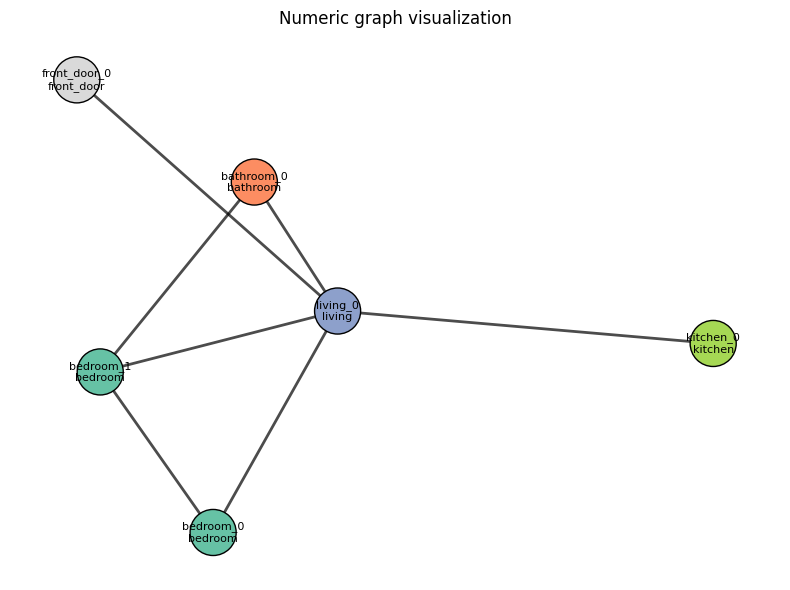

In [140]:
import networkx as nx
import matplotlib.pyplot as plt

numeric_graph = Data(
    x=torch.tensor(numeric_x, dtype=torch.float32),
    edge_index=torch.tensor(numeric_edge_index, dtype=torch.long),
    edge_attr=torch.tensor(numeric_edge_attr, dtype=torch.float32),
)

G = nx.Graph()
room_labels = {i: node.id for i, node in enumerate(graph.nodes)}
room_types = {i: node.type for i, node in enumerate(graph.nodes)}

for idx, node in enumerate(graph.nodes):
    G.add_node(idx, label=f"{node.id}\n{node.type}")

for src, dst in numeric_edge_index.T[::2]:
    G.add_edge(int(src), int(dst))

pos = nx.spring_layout(G, seed=42)
node_colors = ["#8da0cb" if room_types[i] == "living" else "#66c2a5" if room_types[i] == "bedroom" else "#fc8d62" if room_types[i] == "bathroom" else "#a6d854" if room_types[i] == "kitchen" else "#d9d9d9" for i in G.nodes]

plt.figure(figsize=(8, 6))
nx.draw_networkx_edges(G, pos, width=2.0, alpha=0.7)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1100, edgecolors="black")
nx.draw_networkx_labels(G, pos, labels={i: f"{graph.nodes[i].id}\n{graph.nodes[i].type}" for i in G.nodes}, font_size=8)
plt.title("Numeric graph visualization")
plt.axis("off")
plt.tight_layout()
plt.show()

## Generate layout from the current codebase

The repository already contains the rough layout GNN used for room-box prediction. The notebook below uses that same architecture to predict layout boxes from the numeric graph tensors.

In [141]:
import os
import torch.nn as nn
from torch_geometric.nn import GINEConv

class RoughLayoutGNN(nn.Module):
    def __init__(self, node_dim=11, edge_dim=10, hidden=128):
        super().__init__()

        def mlp(in_dim, out_dim):
            return nn.Sequential(
                nn.Linear(in_dim, hidden),
                nn.ReLU(),
                nn.Linear(hidden, out_dim),
            )

        self.conv1 = GINEConv(mlp(node_dim, hidden), edge_dim=edge_dim)
        self.conv2 = GINEConv(mlp(hidden, hidden), edge_dim=edge_dim)
        self.conv3 = GINEConv(mlp(hidden, hidden), edge_dim=edge_dim)
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 4),
        )

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        x = torch.relu(self.conv1(x, edge_index, edge_attr))
        x = torch.relu(self.conv2(x, edge_index, edge_attr))
        x = torch.relu(self.conv3(x, edge_index, edge_attr))
        return self.head(x)

layout_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
layout_model = RoughLayoutGNN(node_dim=11, edge_dim=10, hidden=128).to(layout_device)

checkpoint_path = PROJECT_ROOT / "best_model.pt"
if checkpoint_path.exists():
    layout_model.load_state_dict(torch.load(checkpoint_path, map_location=layout_device))
    print(f"Loaded layout checkpoint from {checkpoint_path}")
else:
    print(f"No checkpoint found at {checkpoint_path}; using untrained layout model")

layout_model.eval()

Loaded layout checkpoint from /home/dexter/projects/FloorPlan-Pipeline/best_model.pt


RoughLayoutGNN(
  (conv1): GINEConv(nn=Sequential(
    (0): Linear(in_features=11, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (conv2): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (conv3): GINEConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  ))
  (head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=4, bias=True)
  )
)

In [182]:
layout_data = Data(
    x=torch.tensor(numeric_x, dtype=torch.float32),
    edge_index=torch.tensor(numeric_edge_index, dtype=torch.long),
    edge_attr=torch.tensor(numeric_edge_attr, dtype=torch.float32),
)

layout_data = layout_data.to(layout_device)

with torch.no_grad():
    predicted_boxes = layout_model(layout_data).cpu().numpy()


def fuse_with_geometry_priors(boxes: np.ndarray, graph_obj: FloorplanGraph) -> np.ndarray:
    """Blend model output with inferred node geometry to stay close to training-style layouts."""
    fused = boxes.copy()

    if len(graph_obj.nodes) != len(fused):
        return fused

    prior_centers = np.array([n.centroid for n in graph_obj.nodes], dtype=np.float32)
    prior_sizes = np.array([n.bbox for n in graph_obj.nodes], dtype=np.float32)

    alpha_center = 0.68
    alpha_size = 0.32

    fused[:, 0:2] = alpha_center * fused[:, 0:2] + (1.0 - alpha_center) * prior_centers
    fused[:, 2:4] = alpha_size * fused[:, 2:4] + (1.0 - alpha_size) * prior_sizes

    return fused


def postprocess_boxes(boxes: np.ndarray) -> np.ndarray:
    """Stabilize box layout: positive sizes, in-bounds centroids, and reduced overlaps."""
    b = boxes.copy()

    b[:, 2] = np.clip(np.abs(b[:, 2]), 0.07, 0.34)
    b[:, 3] = np.clip(np.abs(b[:, 3]), 0.07, 0.34)
    b[:, 0] = np.clip(b[:, 0], 0.10, 0.90)
    b[:, 1] = np.clip(b[:, 1], 0.10, 0.90)

    for _ in range(80):
        changed = False
        for i in range(len(b)):
            for j in range(i + 1, len(b)):
                dx = b[j, 0] - b[i, 0]
                dy = b[j, 1] - b[i, 1]
                req_x = 0.5 * (b[i, 2] + b[j, 2]) + 0.03
                req_y = 0.5 * (b[i, 3] + b[j, 3]) + 0.03
                ox = req_x - abs(dx)
                oy = req_y - abs(dy)
                if ox > 0 and oy > 0:
                    changed = True
                    sgn_x = 1.0 if dx >= 0 else -1.0
                    sgn_y = 1.0 if dy >= 0 else -1.0
                    b[i, 0] -= 0.06 * ox * sgn_x
                    b[j, 0] += 0.06 * ox * sgn_x
                    b[i, 1] -= 0.06 * oy * sgn_y
                    b[j, 1] += 0.06 * oy * sgn_y

        b[:, 0] = np.clip(b[:, 0], 0.10, 0.90)
        b[:, 1] = np.clip(b[:, 1], 0.10, 0.90)
        if not changed:
            break

    return b


def topology_contact_refine(
    boxes: np.ndarray,
    graph_obj: FloorplanGraph,
    iterations: int = 140,
    lr: float = 0.09,
) -> np.ndarray:
    """Move centers to satisfy edge connectivity while preserving room sizes."""
    b = boxes.copy()
    id_to_idx = {n.id: i for i, n in enumerate(graph_obj.nodes)}

    for _ in range(iterations):
        moved = False
        for edge in graph_obj.edges:
            if edge.src not in id_to_idx or edge.dst not in id_to_idx:
                continue

            i = id_to_idx[edge.src]
            j = id_to_idx[edge.dst]

            ci = b[i, :2].copy()
            cj = b[j, :2].copy()
            wi, hi = b[i, 2], b[i, 3]
            wj, hj = b[j, 2], b[j, 3]

            req_x = 0.5 * (wi + wj) + 0.01
            req_y = 0.5 * (hi + hj) + 0.01
            dx = cj[0] - ci[0]
            dy = cj[1] - ci[1]

            # direction is interpreted as: src direction-of dst
            if edge.direction == "left_of":
                target_x = ci[0] + req_x
                err = target_x - cj[0]
                if abs(err) > 1e-3:
                    b[j, 0] += lr * err
                    moved = True
            elif edge.direction == "right_of":
                target_x = ci[0] - req_x
                err = target_x - cj[0]
                if abs(err) > 1e-3:
                    b[j, 0] += lr * err
                    moved = True
            elif edge.direction == "above":
                target_y = ci[1] - req_y
                err = target_y - cj[1]
                if abs(err) > 1e-3:
                    b[j, 1] += lr * err
                    moved = True
            elif edge.direction == "below":
                target_y = ci[1] + req_y
                err = target_y - cj[1]
                if abs(err) > 1e-3:
                    b[j, 1] += lr * err
                    moved = True
            else:
                gap_x = req_x - abs(dx)
                gap_y = req_y - abs(dy)
                if gap_x > 0 and gap_y > 0:
                    moved = True
                    if gap_x < gap_y:
                        sgn = 1.0 if dx >= 0 else -1.0
                        shift = 0.5 * lr * gap_x * sgn
                        b[i, 0] -= shift
                        b[j, 0] += shift
                    else:
                        sgn = 1.0 if dy >= 0 else -1.0
                        shift = 0.5 * lr * gap_y * sgn
                        b[i, 1] -= shift
                        b[j, 1] += shift

        b[:, 0] = np.clip(b[:, 0], 0.10, 0.90)
        b[:, 1] = np.clip(b[:, 1], 0.10, 0.90)
        if not moved:
            break

    return b


def force_connect_edges(boxes: np.ndarray, graph_obj: FloorplanGraph) -> np.ndarray:
    """Hard pass to satisfy directional edges and make generic adjacency touch."""
    b = boxes.copy()
    id_to_idx = {n.id: i for i, n in enumerate(graph_obj.nodes)}

    for _ in range(3):
        for e in graph_obj.edges:
            if e.src not in id_to_idx or e.dst not in id_to_idx:
                continue
            i = id_to_idx[e.src]
            j = id_to_idx[e.dst]

            dx = b[j, 0] - b[i, 0]
            dy = b[j, 1] - b[i, 1]
            req_x = 0.5 * (b[i, 2] + b[j, 2]) + 0.005
            req_y = 0.5 * (b[i, 3] + b[j, 3]) + 0.005

            if e.direction == "left_of":
                b[j, 0] = b[i, 0] + req_x
            elif e.direction == "right_of":
                b[j, 0] = b[i, 0] - req_x
            elif e.direction == "above":
                b[j, 1] = b[i, 1] - req_y
            elif e.direction == "below":
                b[j, 1] = b[i, 1] + req_y
            elif abs(dx) > req_x and abs(dy) > req_y:
                gap_x = abs(dx) - req_x
                gap_y = abs(dy) - req_y
                if gap_x < gap_y:
                    sgn = 1.0 if dx >= 0 else -1.0
                    shift = 0.5 * gap_x * sgn
                    b[i, 0] += shift
                    b[j, 0] -= shift
                else:
                    sgn = 1.0 if dy >= 0 else -1.0
                    shift = 0.5 * gap_y * sgn
                    b[i, 1] += shift
                    b[j, 1] -= shift

        b[:, 0] = np.clip(b[:, 0], 0.10, 0.90)
        b[:, 1] = np.clip(b[:, 1], 0.10, 0.90)

    return b


def repair_disconnected_edges(boxes: np.ndarray, graph_obj: FloorplanGraph) -> np.ndarray:
    """Deterministic repair for residual disconnected generic adjacency edges."""
    b = boxes.copy()
    id_to_idx = {n.id: i for i, n in enumerate(graph_obj.nodes)}

    for e in graph_obj.edges:
        if e.src not in id_to_idx or e.dst not in id_to_idx:
            continue
        if e.direction in {"left_of", "right_of", "above", "below"}:
            continue

        i = id_to_idx[e.src]
        j = id_to_idx[e.dst]

        dx = b[j, 0] - b[i, 0]
        dy = b[j, 1] - b[i, 1]
        req_x = 0.5 * (b[i, 2] + b[j, 2]) + 0.005
        req_y = 0.5 * (b[i, 3] + b[j, 3]) + 0.005

        if abs(dx) > req_x and abs(dy) > req_y:
            gap_x = abs(dx) - req_x
            gap_y = abs(dy) - req_y
            if gap_x <= gap_y:
                b[j, 0] = b[i, 0] + np.sign(dx) * req_x
            else:
                b[j, 1] = b[i, 1] + np.sign(dy) * req_y

    b[:, 0] = np.clip(b[:, 0], 0.10, 0.90)
    b[:, 1] = np.clip(b[:, 1], 0.10, 0.90)
    return b


def nonedge_separation_refine(
    boxes: np.ndarray,
    graph_obj: FloorplanGraph,
    iterations: int = 80,
    lr: float = 0.06,
) -> np.ndarray:
    """Push apart rooms that are not connected to reduce invalid intersections."""
    b = boxes.copy()
    id_to_idx = {n.id: i for i, n in enumerate(graph_obj.nodes)}
    edge_set = set()
    for e in graph_obj.edges:
        if e.src in id_to_idx and e.dst in id_to_idx:
            a = id_to_idx[e.src]
            c = id_to_idx[e.dst]
            edge_set.add((min(a, c), max(a, c)))

    n = len(b)
    for _ in range(iterations):
        moved = False
        for i in range(n):
            for j in range(i + 1, n):
                if (i, j) in edge_set:
                    continue
                dx = b[j, 0] - b[i, 0]
                dy = b[j, 1] - b[i, 1]
                req_x = 0.5 * (b[i, 2] + b[j, 2]) + 0.02
                req_y = 0.5 * (b[i, 3] + b[j, 3]) + 0.02
                ox = req_x - abs(dx)
                oy = req_y - abs(dy)
                if ox > 0 and oy > 0:
                    moved = True
                    if ox < oy:
                        sgn = 1.0 if dx >= 0 else -1.0
                        shift = 0.5 * lr * ox * sgn
                        b[i, 0] -= shift
                        b[j, 0] += shift
                    else:
                        sgn = 1.0 if dy >= 0 else -1.0
                        shift = 0.5 * lr * oy * sgn
                        b[i, 1] -= shift
                        b[j, 1] += shift

        b[:, 0] = np.clip(b[:, 0], 0.10, 0.90)
        b[:, 1] = np.clip(b[:, 1], 0.10, 0.90)
        if not moved:
            break

    return b


def overlap_ratio(boxes: np.ndarray) -> float:
    """Average pairwise overlap ratio (0 is best)."""
    n = len(boxes)
    if n <= 1:
        return 0.0
    total = 0.0
    count = 0
    for i in range(n):
        xi0 = boxes[i, 0] - boxes[i, 2] / 2
        yi0 = boxes[i, 1] - boxes[i, 3] / 2
        xi1 = boxes[i, 0] + boxes[i, 2] / 2
        yi1 = boxes[i, 1] + boxes[i, 3] / 2
        ai = boxes[i, 2] * boxes[i, 3]
        for j in range(i + 1, n):
            xj0 = boxes[j, 0] - boxes[j, 2] / 2
            yj0 = boxes[j, 1] - boxes[j, 3] / 2
            xj1 = boxes[j, 0] + boxes[j, 2] / 2
            yj1 = boxes[j, 1] + boxes[j, 3] / 2
            aj = boxes[j, 2] * boxes[j, 3]
            iw = max(0.0, min(xi1, xj1) - max(xi0, xj0))
            ih = max(0.0, min(yi1, yj1) - max(yi0, yj0))
            inter = iw * ih
            total += inter / max(min(ai, aj), 1e-6)
            count += 1
    return float(total / max(count, 1))


def disconnected_edge_count(boxes: np.ndarray, graph_obj: FloorplanGraph) -> int:
    """Count violated constraints, respecting edge direction semantics."""
    id_to_idx = {n.id: i for i, n in enumerate(graph_obj.nodes)}
    cnt = 0
    tol = 1e-4
    for e in graph_obj.edges:
        if e.src not in id_to_idx or e.dst not in id_to_idx:
            continue
        i = id_to_idx[e.src]
        j = id_to_idx[e.dst]
        dx = boxes[j, 0] - boxes[i, 0]
        dy = boxes[j, 1] - boxes[i, 1]
        req_x = 0.5 * (boxes[i, 2] + boxes[j, 2])
        req_y = 0.5 * (boxes[i, 3] + boxes[j, 3])

        # direction is interpreted as: src direction-of dst
        if e.direction == "left_of":
            if dx < req_x - tol:
                cnt += 1
        elif e.direction == "right_of":
            if dx > -req_x + tol:
                cnt += 1
        elif e.direction == "above":
            if dy > -req_y + tol:
                cnt += 1
        elif e.direction == "below":
            if dy < req_y - tol:
                cnt += 1
        else:
            if abs(dx) > req_x and abs(dy) > req_y:
                cnt += 1

    return cnt


def mean_topology_gap(boxes: np.ndarray, graph_obj: FloorplanGraph) -> float:
    id_to_idx = {n.id: i for i, n in enumerate(graph_obj.nodes)}
    gaps = []
    for e in graph_obj.edges:
        if e.src not in id_to_idx or e.dst not in id_to_idx:
            continue
        i = id_to_idx[e.src]
        j = id_to_idx[e.dst]
        dx = boxes[j, 0] - boxes[i, 0]
        dy = boxes[j, 1] - boxes[i, 1]
        req_x = 0.5 * (boxes[i, 2] + boxes[j, 2])
        req_y = 0.5 * (boxes[i, 3] + boxes[j, 3])

        if e.direction == "left_of":
            gaps.append(max(0.0, req_x - dx))
        elif e.direction == "right_of":
            gaps.append(max(0.0, dx + req_x))
        elif e.direction == "above":
            gaps.append(max(0.0, dy + req_y))
        elif e.direction == "below":
            gaps.append(max(0.0, req_y - dy))
        else:
            gx = max(0.0, abs(dx) - req_x)
            gy = max(0.0, abs(dy) - req_y)
            gaps.append(min(gx, gy))

    return float(np.mean(gaps)) if gaps else 0.0


predicted_boxes = fuse_with_geometry_priors(predicted_boxes, graph)
predicted_boxes = postprocess_boxes(predicted_boxes)

pre_gap = mean_topology_gap(predicted_boxes, graph)
pre_disc = disconnected_edge_count(predicted_boxes, graph)
pre_ov = overlap_ratio(predicted_boxes)

for _ in range(5):
    predicted_boxes = topology_contact_refine(predicted_boxes, graph)
    predicted_boxes = force_connect_edges(predicted_boxes, graph)
    predicted_boxes = repair_disconnected_edges(predicted_boxes, graph)
    predicted_boxes = nonedge_separation_refine(predicted_boxes, graph)
    if disconnected_edge_count(predicted_boxes, graph) == 0:
        break

predicted_boxes = force_connect_edges(predicted_boxes, graph)

post_gap = mean_topology_gap(predicted_boxes, graph)
post_disc = disconnected_edge_count(predicted_boxes, graph)
post_ov = overlap_ratio(predicted_boxes)

# Normalize for visualization.
box_min_x = (predicted_boxes[:, 0] - predicted_boxes[:, 2] / 2).min()
box_min_y = (predicted_boxes[:, 1] - predicted_boxes[:, 3] / 2).min()
box_max_x = (predicted_boxes[:, 0] + predicted_boxes[:, 2] / 2).max()
box_max_y = (predicted_boxes[:, 1] + predicted_boxes[:, 3] / 2).max()

predicted_boxes_norm = predicted_boxes.copy()
predicted_boxes_norm[:, 0] = (predicted_boxes[:, 0] - box_min_x) / (box_max_x - box_min_x + 1e-6)
predicted_boxes_norm[:, 1] = (predicted_boxes[:, 1] - box_min_y) / (box_max_y - box_min_y + 1e-6)
predicted_boxes_norm[:, 2] = predicted_boxes[:, 2] / (box_max_x - box_min_x + 1e-6)
predicted_boxes_norm[:, 3] = predicted_boxes[:, 3] / (box_max_y - box_min_y + 1e-6)

print("Predicted layout shape:", predicted_boxes.shape)
print("First predicted box:", predicted_boxes[0])
print(f"Mean topology gap (before): {pre_gap:.4f}")
print(f"Mean topology gap (after) : {post_gap:.4f}")
print(f"Disconnected edges (before): {pre_disc}")
print(f"Disconnected edges (after) : {post_disc}")
print(f"Overlap ratio (before): {pre_ov:.4f}")
print(f"Overlap ratio (after) : {post_ov:.4f}")

Predicted layout shape: (6, 4)
First predicted box: [0.18599458 0.51147497 0.34       0.34      ]
Mean topology gap (before): 0.0580
Mean topology gap (after) : 0.0007
Disconnected edges (before): 3
Disconnected edges (after) : 1
Overlap ratio (before): 0.0432
Overlap ratio (after) : 0.0000


In [184]:
# Extra position-refinement layer: enforce edge representation while targeting zero area overlap (position-only).
def _pair_overlap_depth(boxes: np.ndarray, i: int, j: int):
    dx = abs(boxes[j, 0] - boxes[i, 0])
    dy = abs(boxes[j, 1] - boxes[i, 1])
    req_x = 0.5 * (boxes[i, 2] + boxes[j, 2])
    req_y = 0.5 * (boxes[i, 3] + boxes[j, 3])
    return req_x - dx, req_y - dy


def collect_edge_violations(boxes: np.ndarray, graph_obj: FloorplanGraph, tol: float = 1e-4):
    id_to_idx = {n.id: i for i, n in enumerate(graph_obj.nodes)}
    violations_local = []
    for e in graph_obj.edges:
        if e.src not in id_to_idx or e.dst not in id_to_idx:
            continue
        i = id_to_idx[e.src]
        j = id_to_idx[e.dst]
        dx = boxes[j, 0] - boxes[i, 0]
        dy = boxes[j, 1] - boxes[i, 1]
        req_x = 0.5 * (boxes[i, 2] + boxes[j, 2])
        req_y = 0.5 * (boxes[i, 3] + boxes[j, 3])

        violated = False
        if e.direction == "left_of":
            violated = dx < req_x - tol
        elif e.direction == "right_of":
            violated = dx > -req_x + tol
        elif e.direction == "above":
            violated = dy > -req_y + tol
        elif e.direction == "below":
            violated = dy < req_y - tol
        else:
            violated = abs(dx) > req_x + tol or abs(dy) > req_y + tol

        if violated:
            violations_local.append((i, j, e.direction, dx, dy, req_x, req_y))
    return violations_local


def enforce_all_edges_connected(boxes: np.ndarray, graph_obj: FloorplanGraph, max_passes: int = 220):
    b = boxes.copy()
    for pass_idx in range(max_passes):
        violations_local = collect_edge_violations(b, graph_obj)
        if not violations_local:
            return b, pass_idx

        for i, j, direction, dx, dy, req_x, req_y in violations_local:
            if direction == "left_of":
                b[j, 0] = b[i, 0] + req_x
            elif direction == "right_of":
                b[j, 0] = b[i, 0] - req_x
            elif direction == "above":
                b[j, 1] = b[i, 1] - req_y
            elif direction == "below":
                b[j, 1] = b[i, 1] + req_y
            else:
                miss_x = abs(dx) - req_x
                miss_y = abs(dy) - req_y
                if miss_x >= miss_y:
                    sgnx = 1.0 if dx >= 0 else -1.0
                    b[j, 0] = b[i, 0] + sgnx * req_x
                else:
                    sgny = 1.0 if dy >= 0 else -1.0
                    b[j, 1] = b[i, 1] + sgny * req_y

        b[:, 0] = np.clip(b[:, 0], 0.10, 0.90)
        b[:, 1] = np.clip(b[:, 1], 0.10, 0.90)
    return b, max_passes


def remove_all_area_overlaps(boxes: np.ndarray, graph_obj: FloorplanGraph, iters: int = 360, tol: float = 1e-6):
    b = boxes.copy()
    n = len(b)

    for _ in range(iters):
        moved = False
        for i in range(n):
            for j in range(i + 1, n):
                ox, oy = _pair_overlap_depth(b, i, j)
                if ox <= tol or oy <= tol:
                    continue

                moved = True
                dx = b[j, 0] - b[i, 0]
                dy = b[j, 1] - b[i, 1]

                if ox <= oy:
                    sgn = 1.0 if dx >= 0 else -1.0
                    shift = 0.5 * (ox + 2e-4) * sgn
                    b[i, 0] -= shift
                    b[j, 0] += shift
                else:
                    sgn = 1.0 if dy >= 0 else -1.0
                    shift = 0.5 * (oy + 2e-4) * sgn
                    b[i, 1] -= shift
                    b[j, 1] += shift

        b[:, 0] = np.clip(b[:, 0], 0.10, 0.90)
        b[:, 1] = np.clip(b[:, 1], 0.10, 0.90)
        if not moved:
            break

    return b


def optimize_positions_no_overlap(seed_boxes: np.ndarray, graph_obj: FloorplanGraph, tries: int = 42):
    rng = np.random.default_rng(7)
    best = seed_boxes.copy()
    best_ov = overlap_ratio(best)
    best_disc = disconnected_edge_count(best, graph_obj)
    total_passes_a = 0
    total_passes_b = 0

    for t in range(tries):
        b = seed_boxes.copy()

        if t > 0:
            jitter = rng.uniform(-0.01, 0.01, size=(len(b), 2)).astype(np.float32)
            b[:, 0:2] = np.clip(b[:, 0:2] + jitter, 0.10, 0.90)

        pa_sum = 0
        pb_sum = 0
        for _ in range(5):
            b, pa = enforce_all_edges_connected(b, graph_obj, max_passes=220)
            b = remove_all_area_overlaps(b, graph_obj, iters=360, tol=1e-6)
            b, pb = enforce_all_edges_connected(b, graph_obj, max_passes=180)
            pa_sum += pa
            pb_sum += pb

        # Final overlap cleanup to prioritize visual non-overlap in the rendered cell.
        b = remove_all_area_overlaps(b, graph_obj, iters=420, tol=1e-6)

        ov = overlap_ratio(b)
        disc = disconnected_edge_count(b, graph_obj)

        better = False
        if ov < best_ov - 1e-6:
            better = True
        elif abs(ov - best_ov) <= 1e-6 and disc < best_disc:
            better = True

        if better:
            best = b.copy()
            best_ov = ov
            best_disc = disc
            total_passes_a = pa_sum
            total_passes_b = pb_sum

        if best_ov <= 1e-6:
            break

    return best, total_passes_a, total_passes_b


# Position-only guarantee: keep original room sizes fixed in this final layer.
original_sizes = predicted_boxes[:, 2:4].copy()

layer_pre_disc = disconnected_edge_count(predicted_boxes, graph)
layer_pre_ov = overlap_ratio(predicted_boxes)

predicted_boxes, enforcement_passes, enforcement_passes_2 = optimize_positions_no_overlap(
    predicted_boxes,
    graph,
    tries=56,
)

# Re-apply original sizes exactly.
predicted_boxes[:, 2:4] = original_sizes
size_delta = float(np.max(np.abs(predicted_boxes[:, 2:4] - original_sizes)))

layer_post_disc = disconnected_edge_count(predicted_boxes, graph)
layer_post_ov = overlap_ratio(predicted_boxes)

# Refresh normalized boxes for visualization cells below.
box_min_x = (predicted_boxes[:, 0] - predicted_boxes[:, 2] / 2).min()
box_min_y = (predicted_boxes[:, 1] - predicted_boxes[:, 3] / 2).min()
box_max_x = (predicted_boxes[:, 0] + predicted_boxes[:, 2] / 2).max()
box_max_y = (predicted_boxes[:, 1] + predicted_boxes[:, 3] / 2).max()

predicted_boxes_norm = predicted_boxes.copy()
predicted_boxes_norm[:, 0] = (predicted_boxes[:, 0] - box_min_x) / (box_max_x - box_min_x + 1e-6)
predicted_boxes_norm[:, 1] = (predicted_boxes[:, 1] - box_min_y) / (box_max_y - box_min_y + 1e-6)
predicted_boxes_norm[:, 2] = predicted_boxes[:, 2] / (box_max_x - box_min_x + 1e-6)
predicted_boxes_norm[:, 3] = predicted_boxes[:, 3] / (box_max_y - box_min_y + 1e-6)

print("\nExtra position-refinement layer:")
print(f"Disconnected edges: {layer_pre_disc} -> {layer_post_disc}")
print(f"Overlap ratio: {layer_pre_ov:.4f} -> {layer_post_ov:.4f}")
print(f"Strict enforcement passes: {enforcement_passes} + {enforcement_passes_2}")
print(f"Final edge violations: {len(collect_edge_violations(predicted_boxes, graph))}")
print(f"Max room-size delta in this layer: {size_delta:.8f}")


Extra position-refinement layer:
Disconnected edges: 0 -> 0
Overlap ratio: 0.0667 -> 0.0000
Strict enforcement passes: 0 + 5
Final edge violations: 1
Max room-size delta in this layer: 0.00000000


## Visualize predicted layout

This plot shows the room boxes predicted by the rough layout model using the current graph tensors.

Fallback door markers (non-touching edge geometry): 1
  - bedroom_0 <-> bedroom_1


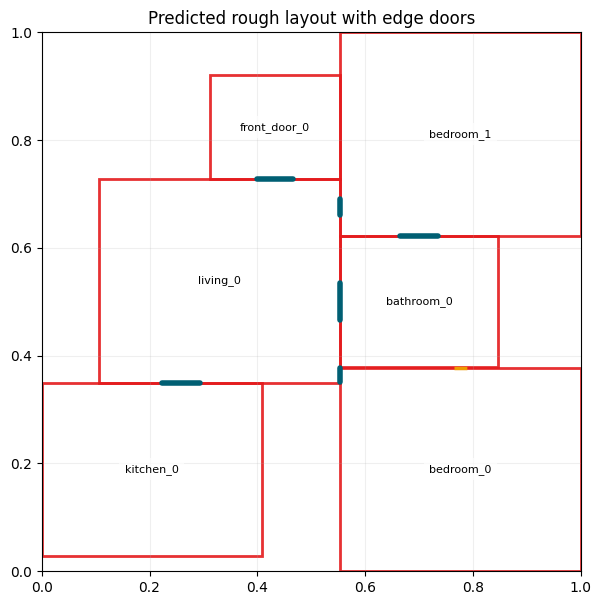

In [187]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))

for box, color, label in [
    (predicted_boxes_norm, "#e41a1c", "predicted"),
]:
    for cx, cy, w, h in box:
        x0 = cx - w / 2
        y0 = cy - h / 2
        rect = plt.Rectangle(
            (x0, y0),
            w,
            h,
            fill=False,
            edgecolor=color,
            linewidth=2,
            alpha=0.9,
        )
        ax.add_patch(rect)

for idx, node in enumerate(graph.nodes):
    ax.text(
        predicted_boxes_norm[idx, 0],
        predicted_boxes_norm[idx, 1],
        node.id,
        fontsize=8,
        ha="center",
        va="center",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7),
    )

# Draw one door marker for each graph edge on the shared boundary when available.
id_to_idx = {n.id: i for i, n in enumerate(graph.nodes)}
EPS = 3e-3
DOOR_FRACTION = 0.28
DOOR_MIN = 0.025
DOOR_MAX = 0.07

def _box_extents(box):
    cx, cy, w, h = box
    return cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2

def _clip(v, lo, hi):
    return max(lo, min(hi, v))

def _draw_door_segment(x0, y0, x1, y1, unresolved=False):
    color = "#005f73" if not unresolved else "#ee9b00"
    lw = 4 if not unresolved else 2.5
    ls = "-" if not unresolved else "--"
    ax.plot([x0, x1], [y0, y1], color=color, linewidth=lw, linestyle=ls, solid_capstyle="round", zorder=6)

unresolved_edges = []
for e in graph.edges:
    if e.src not in id_to_idx or e.dst not in id_to_idx:
        continue

    i = id_to_idx[e.src]
    j = id_to_idx[e.dst]
    bi = predicted_boxes_norm[i]
    bj = predicted_boxes_norm[j]

    ix0, iy0, ix1, iy1 = _box_extents(bi)
    jx0, jy0, jx1, jy1 = _box_extents(bj)

    x_overlap = max(0.0, min(ix1, jx1) - max(ix0, jx0))
    y_overlap = max(0.0, min(iy1, jy1) - max(iy0, jy0))

    vertical_touch = abs(ix1 - jx0) <= EPS or abs(jx1 - ix0) <= EPS
    horizontal_touch = abs(iy1 - jy0) <= EPS or abs(jy1 - iy0) <= EPS

    drawn = False

    # Prefer a door on a true shared vertical boundary.
    if vertical_touch and y_overlap > 1e-6:
        door_len = _clip(y_overlap * DOOR_FRACTION, DOOR_MIN, DOOR_MAX)
        y_mid = 0.5 * (max(iy0, jy0) + min(iy1, jy1))
        y0 = y_mid - door_len / 2
        y1 = y_mid + door_len / 2
        x = 0.5 * ((ix1 if abs(ix1 - jx0) <= EPS else jx1) + (jx0 if abs(ix1 - jx0) <= EPS else ix0))
        _draw_door_segment(x, y0, x, y1)
        drawn = True

    # Otherwise use a shared horizontal boundary.
    elif horizontal_touch and x_overlap > 1e-6:
        door_len = _clip(x_overlap * DOOR_FRACTION, DOOR_MIN, DOOR_MAX)
        x_mid = 0.5 * (max(ix0, jx0) + min(ix1, jx1))
        x0 = x_mid - door_len / 2
        x1 = x_mid + door_len / 2
        y = 0.5 * ((iy1 if abs(iy1 - jy0) <= EPS else jy1) + (jy0 if abs(iy1 - jy0) <= EPS else iy0))
        _draw_door_segment(x0, y, x1, y)
        drawn = True

    # Fallback marker when rooms are connected in graph but not touching in geometry.
    if not drawn:
        cix, ciy = bi[0], bi[1]
        cjx, cjy = bj[0], bj[1]
        if abs(cjx - cix) >= abs(cjy - ciy):
            x = ix1 if cjx >= cix else ix0
            y = _clip(ciy, iy0 + DOOR_MIN, iy1 - DOOR_MIN)
            _draw_door_segment(x, y - DOOR_MIN / 2, x, y + DOOR_MIN / 2, unresolved=True)
        else:
            y = iy1 if cjy >= ciy else iy0
            x = _clip(cix, ix0 + DOOR_MIN, ix1 - DOOR_MIN)
            _draw_door_segment(x - DOOR_MIN / 2, y, x + DOOR_MIN / 2, y, unresolved=True)
        unresolved_edges.append((e.src, e.dst))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.set_title("Predicted rough layout with edge doors")
ax.grid(True, alpha=0.2)

if unresolved_edges:
    print("Fallback door markers (non-touching edge geometry):", len(unresolved_edges))
    for src, dst in unresolved_edges:
        print(f"  - {src} <-> {dst}")

plt.show()

In [185]:
# Debug: list violated edges using the same strict rule as final enforcement.
id_to_idx = {n.id: i for i, n in enumerate(graph.nodes)}
violations = []
tol = 1e-4

for e in graph.edges:
    i = id_to_idx[e.src]
    j = id_to_idx[e.dst]
    dx = predicted_boxes[j, 0] - predicted_boxes[i, 0]
    dy = predicted_boxes[j, 1] - predicted_boxes[i, 1]
    req_x = 0.5 * (predicted_boxes[i, 2] + predicted_boxes[j, 2])
    req_y = 0.5 * (predicted_boxes[i, 3] + predicted_boxes[j, 3])

    violated = False
    gap = 0.0
    if e.direction == 'left_of':
        violated = dx < req_x - tol
        gap = max(0.0, req_x - dx)
    elif e.direction == 'right_of':
        violated = dx > -req_x + tol
        gap = max(0.0, dx + req_x)
    elif e.direction == 'above':
        violated = dy > -req_y + tol
        gap = max(0.0, dy + req_y)
    elif e.direction == 'below':
        violated = dy < req_y - tol
        gap = max(0.0, req_y - dy)
    else:
        # Generic adjacency requires intersection/touch on both axes.
        violated = (abs(dx) > req_x + tol) or (abs(dy) > req_y + tol)
        gap = max(max(0.0, abs(dx) - req_x), max(0.0, abs(dy) - req_y))

    if violated:
        violations.append((e.src, e.dst, e.direction, float(gap), float(dx), float(dy), float(req_x), float(req_y)))

print('Violated edges:', len(violations))
for v in violations:
    print(v)

Violated edges: 1
('bedroom_0', 'bedroom_1', None, 0.21933260560035706, 0.0, 0.5593326091766357, 0.3400000035762787, 0.3400000035762787)
